In [1]:
import pandas as pd
import csv
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



# Aqui vou passar as máscras reais, geradas pela simulação
# Training 6000



In [2]:
def load_data(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])

    # Corrigindo os parâmetros do R02 para árvores com pouca mutação
    n_de_mutantes = np.load(f'mutation_dataset_10-06_v{v}\\number_of_mutantes.npy')
    n_de_mutantes = np.delete(n_de_mutantes, simulacoes_com_erro)
    sem_mutação = np.where(n_de_mutantes <= 5)
    R_nought2[sem_mutação[0]] = R_nought1[sem_mutação[0]]

    # Corrigindo o R01 para árvores em que a mutação é mais de 95% dos nós
    n_nos = np.count_nonzero(trees_cblv, axis=1)
    proporcao_mutacao = n_de_mutantes / n_nos
    muita_mutacao = np.where(proporcao_mutacao > 0.95)
    R_nought1[muita_mutacao[0]] = R_nought2[muita_mutacao[0]]


    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)

    mutation_masks = np.load(f'mutation_dataset_10-06_v{v}\\mutation_masks.npy')
    mutation_masks = np.delete(mutation_masks, simulacoes_com_erro, axis=0)

    vectorized = np.column_stack((R_nought1, R_nought2, infectious_time_div_reascale))

    masked = np.multiply(trees_cblv, mutation_masks)
    trees_cblv_and_masked = np.column_stack((trees_cblv, masked))

    return trees_cblv_and_masked, vectorized, rescale_factors

In [3]:
X, y, rescale_factors = load_data(0)

In [4]:
print(X.shape)
print(y.shape)

(99994, 2004)
(99994, 3)


In [5]:
test_size = 10000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [6]:
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [7]:
modelo = tf.keras.models.load_model("modelos\\9000\\modelo.keras")

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 501, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 499, 50)        │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 490, 50)        │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 80)         │        40,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 80)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,207 (864.09 KB)

 Trainable params: 73,735 (288.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 147,472 (576.07 KB)

In [ ]:
modelo = tf.keras.models.Sequential([
    layers.Input(X_train[0].shape),
    layers.Reshape((501, 4)),
    layers.Conv1D(filters = 50, kernel_size = 3, activation='relu'),
    layers.Conv1D(filters = 50, kernel_size = 10, activation='relu'),
    layers.MaxPooling1D(pool_size=10),
    layers.Conv1D(filters = 80, kernel_size = 10, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='elu'),
    layers.Dense(32, activation='elu'),
    layers.Dense(16, activation='elu'),
    layers.Dense(8, activation='elu'),
    #layers.Dense(2, activation='elu'),
    layers.Dense(3, activation='linear')
    ])

modelo.compile(optimizer='adam',loss='mse',metrics=['mse'])
modelo.summary()

In [ ]:
early_stop = EarlyStopping(monitor='val_mse', mode='min', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_mse', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
history = modelo.fit(X_train, y_train, epochs=500, batch_size=32, callbacks=[early_stop], validation_split=0.01, verbose=1)

In [ ]:
pred = modelo.predict(X_test)
pred = scaler.inverse_transform(pred)
pred[:, 2] *= rescale_factors[-test_size:]



In [ ]:
#run it once!
y_test = scaler.inverse_transform(y_test)
y_test[:, 2] *= rescale_factors[-test_size:]

In [ ]:
mse_r01 = np.mean((pred[:,0] - y_test[:,0])**2)
mse_r02 = np.mean((pred[:,1] - y_test[:,1])**2)
mse_inf = np.mean((pred[:,2] - y_test[:,2])**2)



print("MSE R01:", mse_r01)
print("MSE R02:", mse_r02)
print("MSE Inf:", mse_inf)

In [ ]:
erros = np.abs(pred - y_test)
mae_por_variavel = np.mean(erros, axis=0)

print("MAE R01:", mae_por_variavel[0])
print("MAE R02:", mae_por_variavel[1])
print("MAE Inf:", mae_por_variavel[2])

In [ ]:
erro_relativo = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R01:", erro_relativo[0])
print("MAPE R02:", erro_relativo[1])
print("MAPE Inf:", erro_relativo[2])

In [ ]:
corr_r01 = np.corrcoef(y_test[:,0], pred[:,0])[0,1]
corr_r02 = np.corrcoef(y_test[:,1], pred[:,1])[0,1]
corr_inf = np.corrcoef(y_test[:,2], pred[:,2])[0,1]
print("CORR R01:", corr_r01)
print("CORR R02:", corr_r02)
print("CORR Inf:", corr_inf)

In [ ]:
print(f'''     & R01     & R02    & INF   \\\ \hline
MSE  & {mse_r01:.4f}  & {mse_r02:.4f} & {mse_inf:.4f} \\\ \hline
MAE  & {mae_por_variavel[0]:.4f} & {mae_por_variavel[1]:.4f} & {mae_por_variavel[2]:.4f} \\\ \hline
MAPE & {erro_relativo[0]:.4f}  & {erro_relativo[1]:.4f} & {erro_relativo[2]:.4f} \\\ \hline
CORR & {corr_r01:.4f}  & {corr_r02:.4f} & {corr_inf:.4f} \\\ \hline''')

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# y_true and y_pred: shape (n_samples, 3)

mape = np.abs((y_test - pred) / y_test) * 100
mape = mape[:300]
fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(
    data=[mape[:, 0], mape[:, 1], mape[:, 2]],
    jitter=0.25,
    size=5
)




sns.stripplot(
    data=mape,
    jitter=0.25,
    size=5,
    ax=ax
)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([r"$R_{01}$", r"$R_{02}$", r"$\frac{1}{\gamma}$" ], fontsize=16)

ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE distribution — first 100 observations")

# Numbers to display below each column
numbers = [0.09, f"{0.11:.2f}", 0.06]

# Get the colors used by the three columns
colors = sns.color_palette(n_colors=3)

for x, number, color in zip(range(3), numbers, colors):


    ax.text(
        x, -0.12,
        str(number),
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        color=color,
        fontsize=16,
        fontweight="bold"
    )

plt.xticks([0, 1, 2], [r"$R_{01}$", r"$R_{02}$", r"$1/\gamma$"]  )
plt.ylabel("MAPE (%)", fontsize=16)
plt.title("MAPE por parâmetro", fontsize=16)
ax.set_ylim(0, 120)
plt.savefig("jitter_plots\\mape_CBLV_avec_true_mask.pdf", bbox_inches="tight")
plt.show()

In [ ]:
path = "modelos\\9400"

modelo.save(path + "\\modelo.keras")

with open(path + "\\scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(path + "\\history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss MSE')
plt.legend()
plt.grid(True)
plt.axvline(x=(early_stop.best_epoch ), color='red', linestyle='--', linewidth=1.5)

plt.savefig(path + "\\loss_curve_MSE.pdf", format="pdf", bbox_inches="tight")
plt.savefig(path + "\\loss_curve_MSE.png", dpi=600, bbox_inches="tight")

plt.show()

## Agora eu vou passar o CLBV com as mascaras predizidas no nn_mask_prediction

In [ ]:
modelo = tf.keras.models.load_model("C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\neural_networks_dot_keras\\04-07\\mask_in_X\\modelo_mask_in_X_04-07.keras")

In [28]:
mask_pred = np.load("C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\neural_networks_dot_keras\\04-07\\mask_prediction\\pred_mask_04-07_v0.npy")


X_test_avec_mask = np.column_stack((X_test[:, :1002], np.multiply(X_test[:, :1002], mask_pred)))
X_test_avec_mask_binary = np.column_stack((X_test[:, :1002], np.multiply(X_test[:, :1002], (mask_pred > 0.8).astype(int))))

In [29]:
pred = modelo.predict(X_test_avec_mask_binary)
pred = scaler.inverse_transform(pred)
pred[:, 2] *= rescale_factors[-test_size:]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [10]:
# Run it once!
y_test = scaler.inverse_transform(y_test)
y_test[:, 2] *= rescale_factors[-test_size:]

In [30]:
erros = np.abs(pred - y_test)
mae_por_variavel = np.mean(erros, axis=0)

print("MAE R0:", mae_por_variavel[0])
print("MAE infectious_time:", mae_por_variavel[1])
print("MAE proportion:", mae_por_variavel[2])

MAE R0: 0.5154486521327493
MAE infectious_time: 1.4824666590934257
MAE proportion: 0.4737132058037484


In [31]:
erro_relativo = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("Erro relativo R0:", erro_relativo[0])
print("Erro relativo time:", erro_relativo[1])
print("Erro relativo proportion:", erro_relativo[2])

Erro relativo R0: 0.1789076566434261
Erro relativo time: 0.3025619672612813
Erro relativo proportion: 0.08305682331116694


In [25]:
print(np.corrcoef(y_test[:,0], pred[:,0])[0,1])
print(np.corrcoef(y_test[:,1], pred[:,1])[0,1])
print(np.corrcoef(y_test[:,2], pred[:,2])[0,1])

0.7842580442598047
0.7899780959269681
0.9415892727980896


In [32]:
erro_relativo = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R0:", erro_relativo[0])
print("MAPE time:", erro_relativo[1])
print("MAPE proportion:", erro_relativo[2])

MAPE R0: 0.1789076566434261
MAPE time: 0.3025619672612813
MAPE proportion: 0.08305682331116694


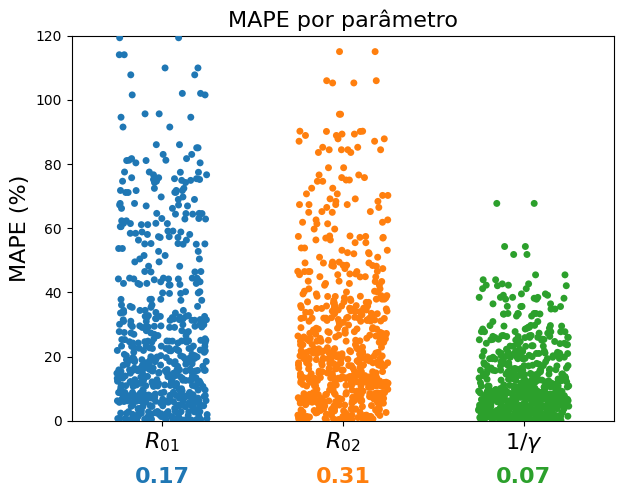

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# y_true and y_pred: shape (n_samples, 3)

mape = np.abs((y_test - pred) / y_test) * 100
mape = mape[:300]
fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(
    data=[mape[:, 0], mape[:, 1], mape[:, 2]],
    jitter=0.25,
    size=5
)




sns.stripplot(
    data=mape,
    jitter=0.25,
    size=5,
    ax=ax
)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([r"$R_{01}$", r"$R_{02}$", r"$\frac{1}{\gamma}$" ], fontsize=16)

ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE distribution — first 100 observations")

# Numbers to display below each column
numbers = [0.17, f"{0.31:.2f}", 0.07]

# Get the colors used by the three columns
colors = sns.color_palette(n_colors=3)

for x, number, color in zip(range(3), numbers, colors):


    ax.text(
        x, -0.12,
        str(number),
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        color=color,
        fontsize=16,
        fontweight="bold"
    )

plt.xticks([0, 1, 2], [r"$R_{01}$", r"$R_{02}$", r"$1/\gamma$"]  )
plt.ylabel("MAPE (%)", fontsize=16)
plt.title("MAPE por parâmetro", fontsize=16)
ax.set_ylim(0, 120)
plt.savefig("jitter_plots\\mape_CBLV_avec_pred_mask.pdf", bbox_inches="tight")
plt.show()